# UCI Adult 收入数据集：完整 EDA + 机器学习建模

> 数据来源：`raw-data/adult.data`（UCI Machine Learning Repository, Census Income / Adult 数据集，无表头 CSV）
> 目标：分析人群特征并预测年收入是否大于 50K 美元

**字段说明（15 列）**

| 类别 | 列名 | 类型 | 说明 |
| --- | --- | --- | --- |
| 数值 | age | int | 年龄 |
| 数值 | fnlwgt | int | final weight，人口权重 |
| 数值 | education-num | int | 学历数值化（1–16） |
| 数值 | capital-gain | int | 资本收益 |
| 数值 | capital-loss | int | 资本损失 |
| 数值 | hours-per-week | int | 每周工作小时 |
| 类别 | workclass | str | 雇佣类型 |
| 类别 | education | str | 学历 |
| 类别 | marital-status | str | 婚姻状况 |
| 类别 | occupation | str | 职业 |
| 类别 | relationship | str | 家庭角色 |
| 类别 | race | str | 种族 |
| 类别 | sex | str | 性别 |
| 类别 | native-country | str | 原籍 |
| 目标 | income | str | `<=50K` / `>50K` |

**注意**：原数据集中缺失值以 `" ?"`（带前导空格）出现。

## 1. 准备：导入库与全局设置

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

ROOT = Path(".").resolve()
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("环境就绪")

环境就绪


## 2. 载入与初步清洗

In [2]:
# UCI Adult 列名（15 列）
COLUMNS = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
NUM_COLS = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
CAT_COLS = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
TARGET = "income"

raw = pd.read_csv(
    ROOT / "raw-data" / "adult.data",
    header=None,
    names=COLUMNS,
    na_values="?",           # skipinitialspace=True 后 ' ?' 变成 '?'
    skipinitialspace=True,   # 去掉 ' State-gov' 之类的前导空格
)

print("原始 shape:", raw.shape)
print("唯一 income 取值:", raw["income"].unique())
raw.head()

原始 shape: (32561, 15)
唯一 income 取值: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# 处理空行 / 全 NaN 行；去重
df = raw.dropna(how="all").drop_duplicates().reset_index(drop=True)
print("清洗后 shape:", df.shape)
print("各列缺失值数量：")
print(df.isna().sum().sort_values(ascending=False))

清洗后 shape: (32537, 15)
各列缺失值数量：
occupation        1843
workclass         1836
native-country     582
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64


In [4]:
# 数据基本信息
print("dtypes:")
print(df.dtypes)
print("\n数值列描述统计：")
display(df[NUM_COLS].describe().T.round(2))
print("\n类别列唯一值数量：")
display(df[CAT_COLS + [TARGET]].nunique().sort_values(ascending=False).to_frame("unique"))

dtypes:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

数值列描述统计：


,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.59,13.64,17.0,28.0,37.0,48.0,90.0
fnlwgt,32537.0,189780.85,105556.47,12285.0,117827.0,178356.0,236993.0,1484705.0
education-num,32537.0,10.08,2.57,1.0,9.0,10.0,12.0,16.0
capital-gain,32537.0,1078.44,7387.96,0.0,0.0,0.0,0.0,99999.0
capital-loss,32537.0,87.37,403.10,0.0,0.0,0.0,0.0,4356.0
hours-per-week,32537.0,40.44,12.35,1.0,40.0,40.0,45.0,99.0



类别列唯一值数量：


,unique
native-country,41
education,16
occupation,14
workclass,8
marital-status,7
relationship,6
race,5
sex,2
income,2


## 3. 单变量 EDA

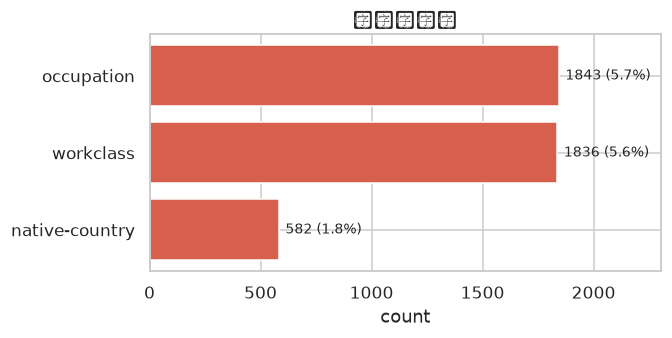

In [5]:
# 3.1 缺失值条形图
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(miss.index, miss.values, color="#d6604d")
for i, v in enumerate(miss.values):
    ax.text(v + 30, i, f"{v} ({v/len(df)*100:.1f}%)", va="center", fontsize=9)
ax.set_xlim(0, miss.max() * 1.25)
ax.set_title("缺失值数量")
ax.set_xlabel("count")
plt.savefig(FIG / "01_missing.png")
plt.show()

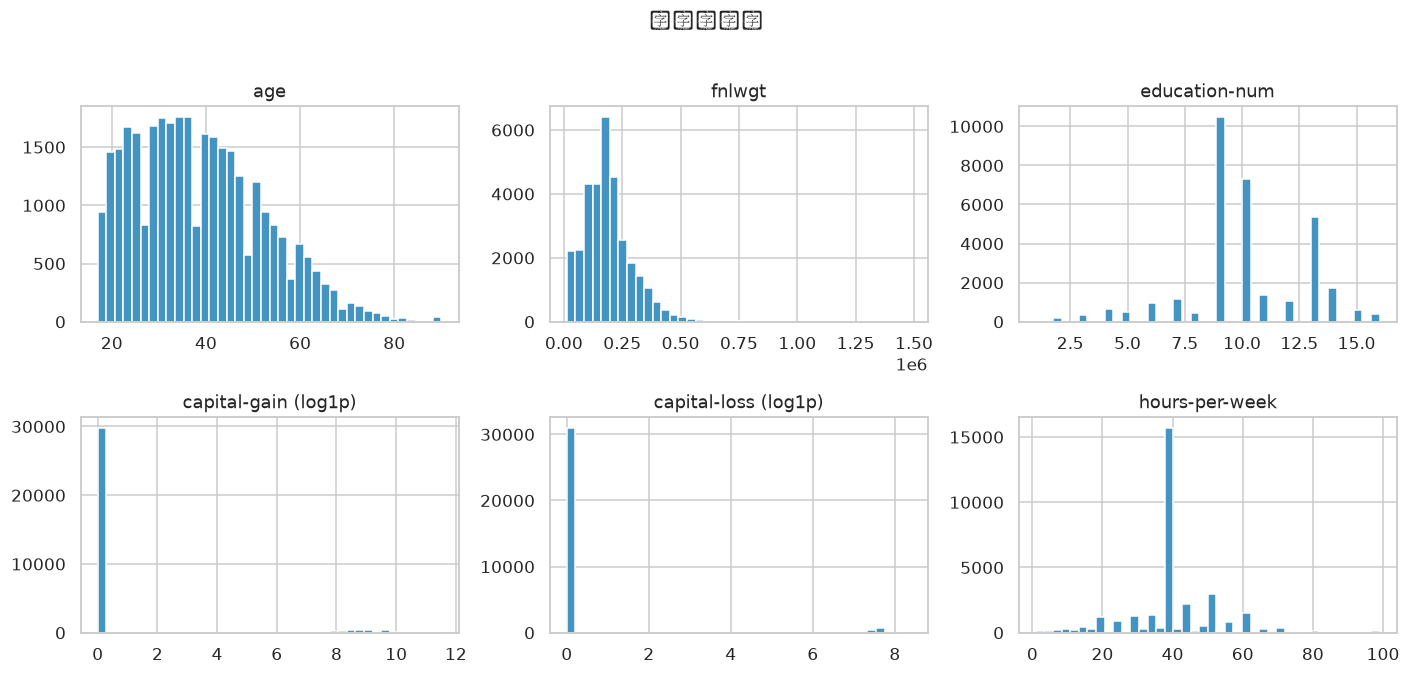

In [6]:
# 3.2 数值列直方图
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.ravel(), NUM_COLS):
    data = df[c].dropna().to_numpy()
    # capital-gain/loss 极端稀疏，用 log 视角更清楚
    if c in ("capital-gain", "capital-loss"):
        ax.hist(np.log1p(data), bins=40, color="#4393c3", edgecolor="white")
        ax.set_title(f"{c} (log1p)")
    else:
        ax.hist(data, bins=40, color="#4393c3", edgecolor="white")
        ax.set_title(c)
plt.suptitle("数值列分布", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "02_num_hist.png")
plt.show()

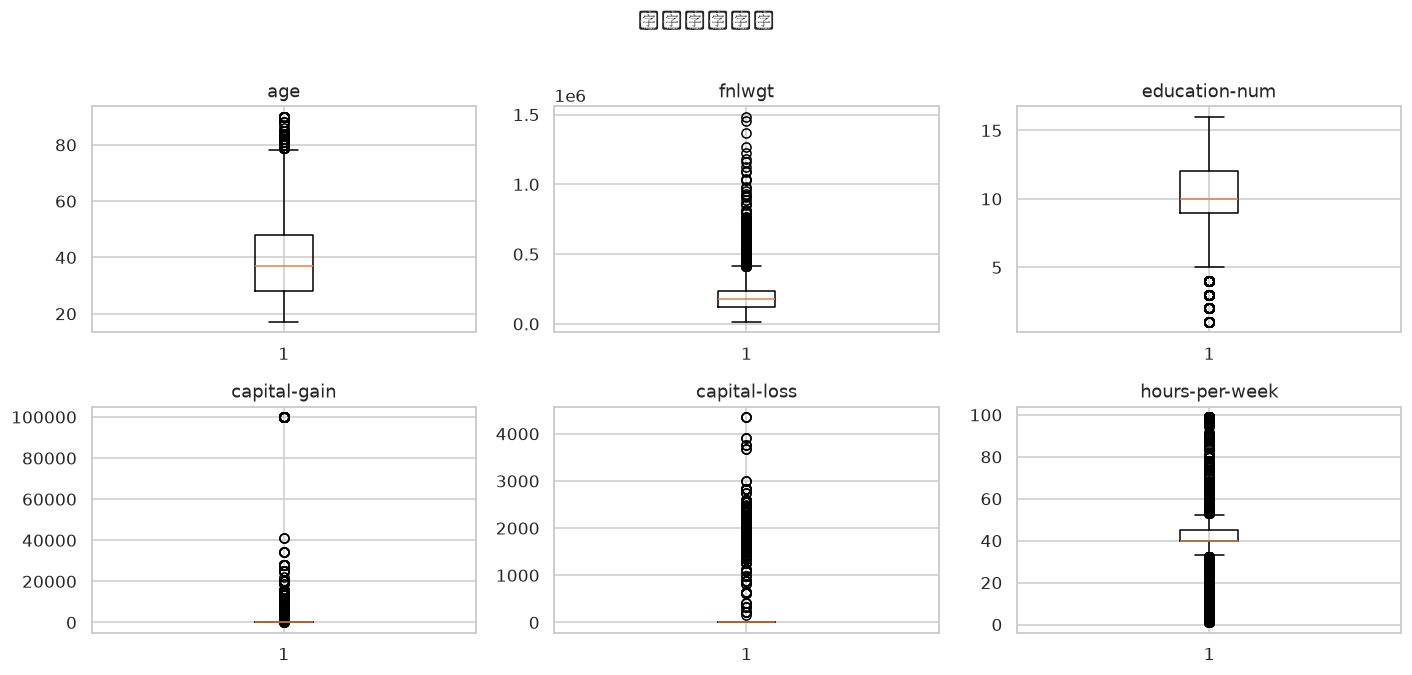

In [7]:
# 3.3 数值列箱线图（看离群点）
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.ravel(), NUM_COLS):
    ax.boxplot(df[c].dropna(), vert=True)
    ax.set_title(c)
    ax.set_ylabel("")
plt.suptitle("数值列箱线图", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "03_num_box.png")
plt.show()

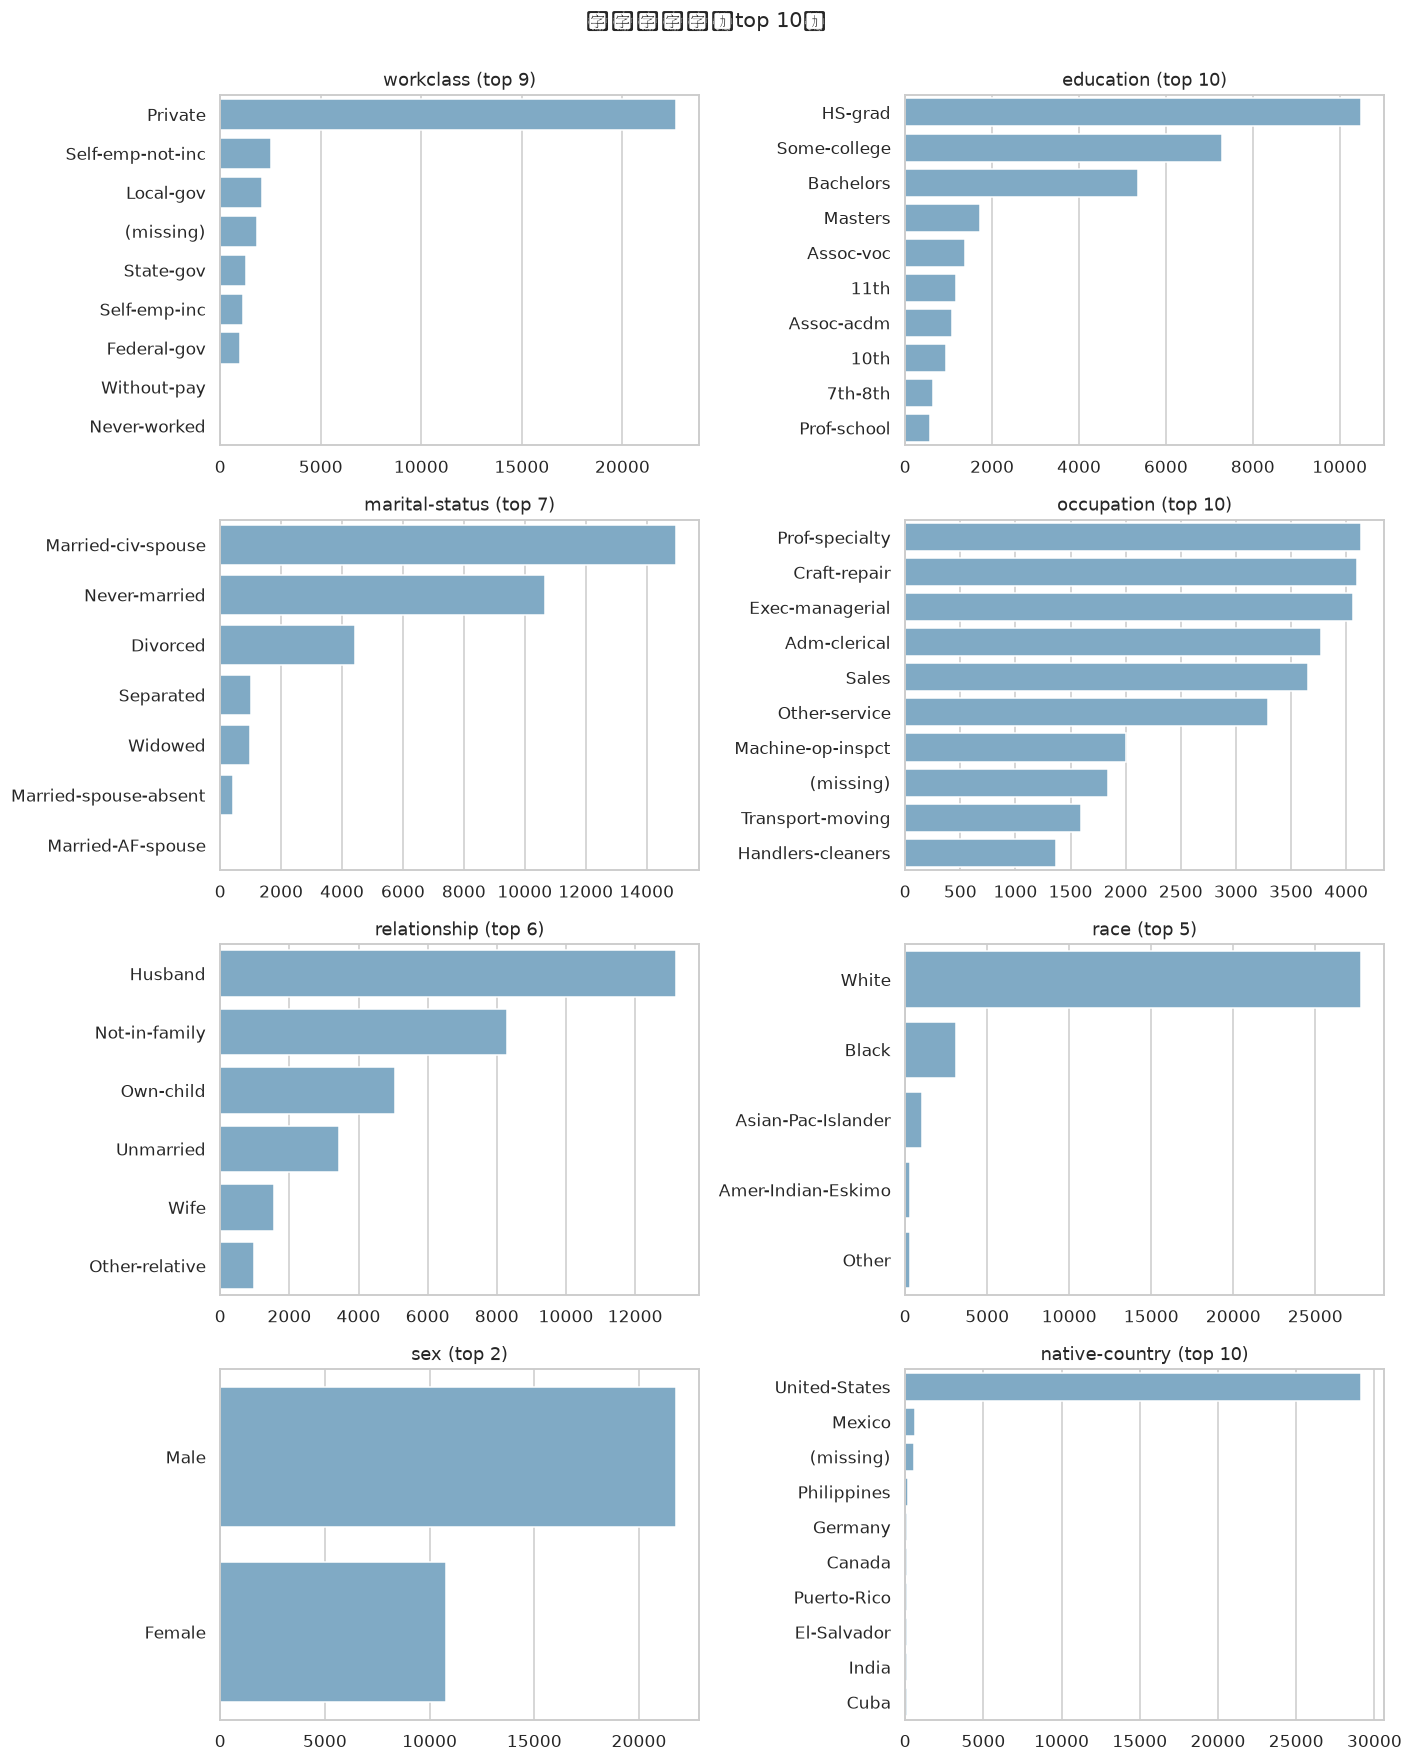

In [8]:
# 3.4 类别列 top 占比（用临时 series 替代 NaN，便于排序）
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, c in zip(axes.ravel(), CAT_COLS):
    s = df[c].fillna("(missing)")
    vc = s.value_counts().head(10)
    order = vc.index.tolist()
    sns.countplot(y=c, data=df.assign(**{c: s}), order=order, ax=ax, color="#74add1")
    ax.set_title(f"{c} (top {len(vc)})")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("类别列频次（top 10）", y=1.0, fontsize=14)
plt.tight_layout()
plt.savefig(FIG / "04_cat_bar.png")
plt.show()

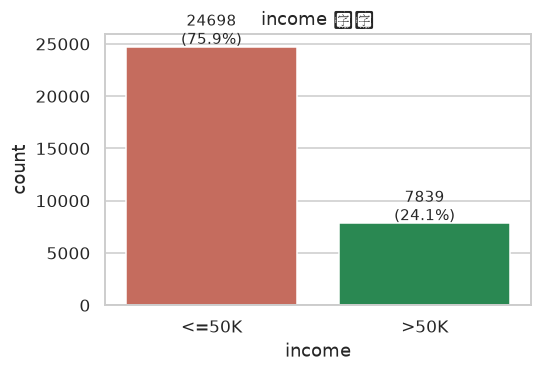

In [9]:
# 3.5 目标变量分布
fig, ax = plt.subplots(figsize=(5, 3.2))
vc = df[TARGET].value_counts()
sns.barplot(x=vc.index, y=vc.values, ax=ax, palette=["#d6604d", "#1a9850"])
for i, v in enumerate(vc.values):
    ax.text(i, v + 300, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
ax.set_title("income 分布")
ax.set_ylabel("count")
plt.savefig(FIG / "05_target.png")
plt.show()

## 4. 双变量 EDA：income vs 各特征

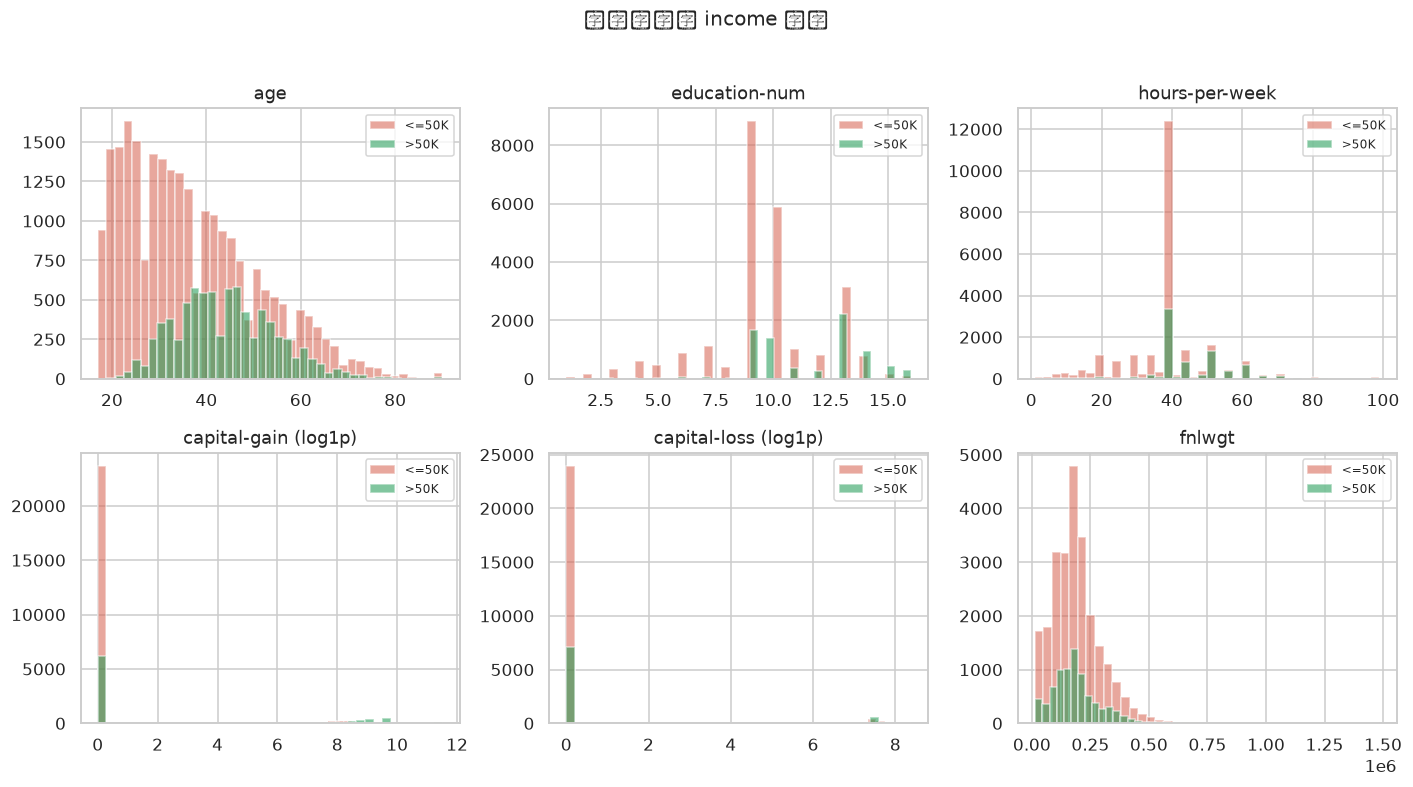

In [10]:
# 4.1 数值特征按 income 分组（age / education-num / hours-per-week）
pairs = [("age", None), ("education-num", None), ("hours-per-week", None),
         ("capital-gain", "log1p"), ("capital-loss", "log1p"), ("fnlwgt", None)]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
target_arr = df[TARGET].to_numpy()
for ax, (c, t) in zip(axes.ravel(), pairs):
    base = df[c].to_numpy()
    if t == "log1p":
        vals = np.log1p(base)
    else:
        vals = base
    for label, color in [("<=50K", "#d6604d"), (">50K", "#1a9850")]:
        sub = vals[target_arr == label]
        ax.hist(sub, bins=40, alpha=0.55, label=label, color=color, edgecolor="white")
    ax.set_title(f"{c}" + (f" ({t})" if t else ""))
    ax.legend(fontsize=8)
plt.suptitle("数值特征按 income 分布", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "06_num_by_income.png")
plt.show()

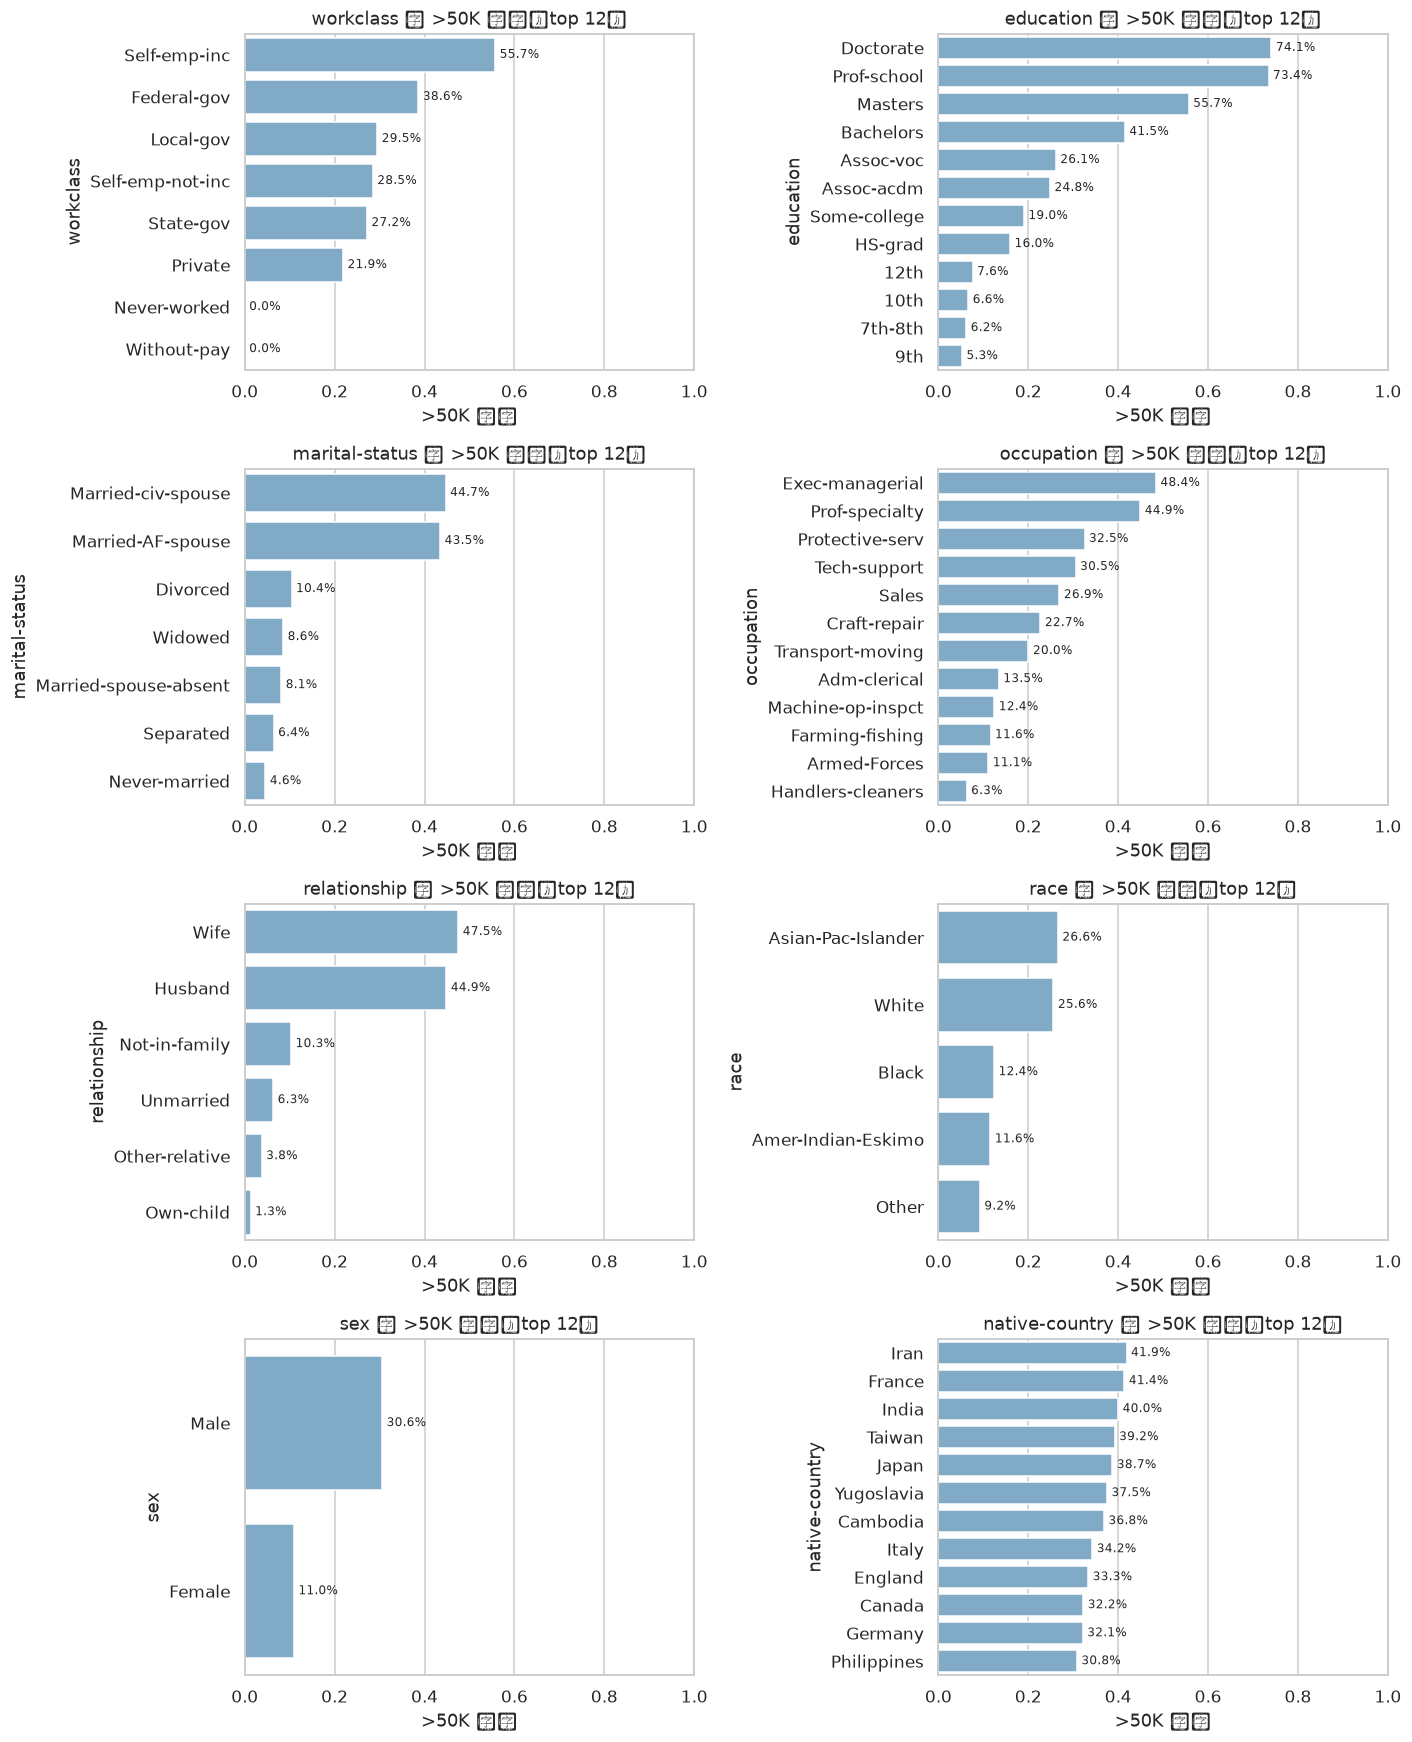

In [11]:
# 4.2 类别特征 vs income（>50K 比例）
rows = []
for c in CAT_COLS:
    tmp = df.groupby(c)[TARGET].apply(lambda s: (s == ">50K").mean()).reset_index()
    tmp.columns = [c, "ratio"]
    tmp["feature"] = c
    rows.append(tmp)
prop = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, c in zip(axes.ravel(), CAT_COLS):
    sub = prop[prop["feature"] == c].sort_values("ratio", ascending=False).head(12)
    sns.barplot(y=c, x="ratio", data=sub, ax=ax, color="#74add1")
    ax.set_title(f"{c} 中 >50K 比例（top 12）")
    ax.set_xlim(0, 1)
    ax.set_xlabel(">50K 占比")
    for i, r in sub.reset_index(drop=True).iterrows():
        ax.text(r["ratio"] + 0.01, i, f"{r['ratio']*100:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "07_cat_vs_income.png")
plt.show()

## 5. 多变量 EDA

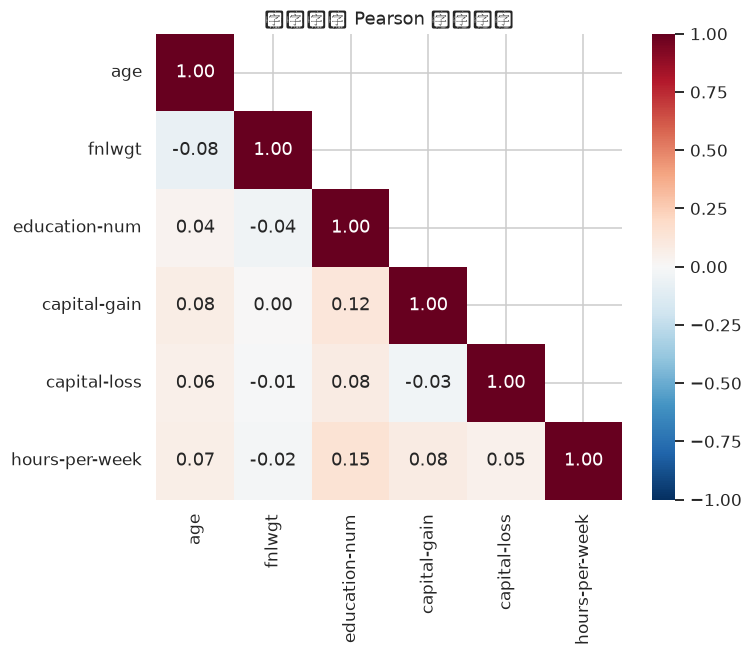

In [12]:
# 5.1 数值特征相关矩阵
corr = df[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, ax=ax, square=True
)
ax.set_title("数值特征 Pearson 相关矩阵")
plt.savefig(FIG / "08_corr.png")
plt.show()

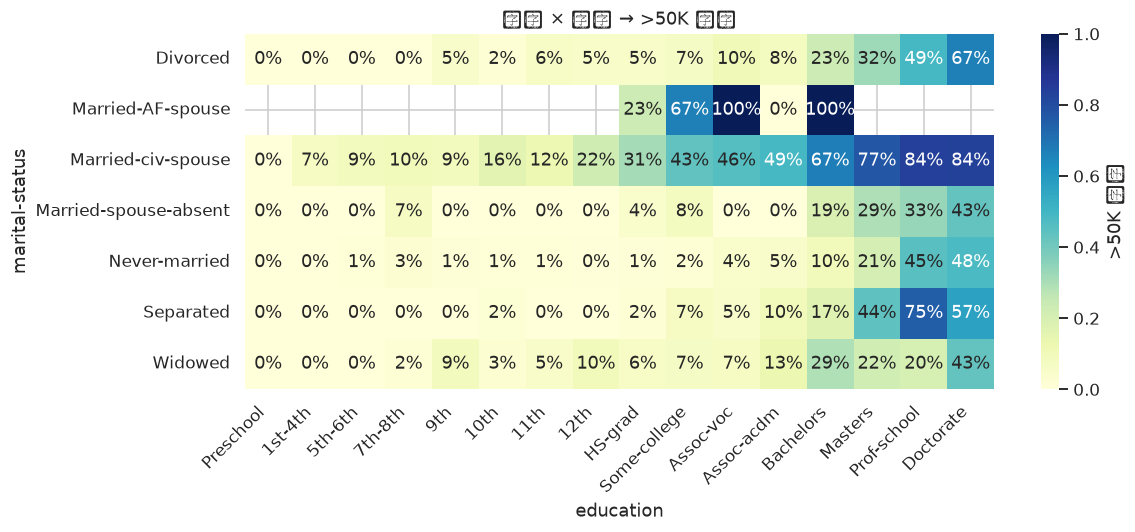

In [13]:
# 5.2 学历 × 婚姻状况 → income 比例热力图
edu_order = (
    df.groupby("education")["education-num"].mean().sort_values().index.tolist()
)
pivot = (
    df.assign(hi=lambda d: (d[TARGET] == ">50K").astype(int))
      .pivot_table(index="marital-status", columns="education",
                   values="hi", aggfunc="mean")
      .reindex(columns=edu_order)
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlGnBu", ax=ax, cbar_kws={"label": ">50K 占比"})
ax.set_title("婚姻 × 学历 → >50K 比例")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG / "09_edu_marital_heat.png")
plt.show()

### 5.3 EDA 关键洞察

1. **样本规模**：32,561 条记录，6 个数值列，9 个类别列（含目标），3 个类别列存在少量 `?` 缺失（workclass / occupation / native-country）。
2. **类别不平衡**：`<=50K` 占 75.9%，`>50K` 占 24.1%——典型的轻度不平衡二分类，accuracy 不够用，应关注 ROC-AUC / F1。
3. **capital-gain / capital-loss 极度右偏**：>90% 为 0，长尾少数离群点。已用 `log1p` 视角展示。
4. **age / education-num / hours-per-week 与 income 明显正相关**：高收入群体年龄更大、学历更高、工时更长。
5. **强区分度的类别特征**：
   - `marital-status`：`Married-civ-spouse` 的 >50K 比例显著高于其他组；
   - `relationship`：`Husband` / `Wife` 同样远高于 `Own-child` / `Not-in-family`；
   - `sex`：男性 >50K 比例约为女性的 3 倍；
   - `education` / `education-num`：随学历阶梯单调上升。
6. **native-country 高度不均衡**：`United-States` 占比 ~89%，其他国家样本过少，模型中应谨慎对待其系数。

## 6. 数据预处理

In [14]:
# 6.1 处理缺失：类别列用众数填补
for c in CAT_COLS:
    if df[c].isna().any():
        mode = df[c].mode().iloc[0]
        df[c] = df[c].fillna(mode)
        print(f"  填补 {c} -> {mode}")

# 6.2 目标二值化
df["income_bin"] = (df[TARGET].str.strip() == ">50K").astype(int)
print("目标分布（0/1）：", df["income_bin"].value_counts().to_dict())

  填补 workclass -> Private
  填补 occupation -> Prof-specialty
  填补 native-country -> United-States
目标分布（0/1）： {0: 24698, 1: 7839}


In [15]:
# 6.3 One-Hot 编码 + 划分训练/测试
X = pd.get_dummies(df[NUM_COLS + CAT_COLS], drop_first=True)
y = df["income_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("X_train:", X_train.shape, "  X_test:", X_test.shape)
print("特征维度：", X.shape[1])

X_train: (26029, 97)   X_test: (6508, 97)
特征维度： 97


## 7. 建模与评估

,model,CV_AUC,CV_F1
3,GradientBoosting,0.9200,0.6785
2,RandomForest,0.9026,0.6680
1,DecisionTree,0.8923,0.6671
0,LogisticRegression,0.8881,0.6343


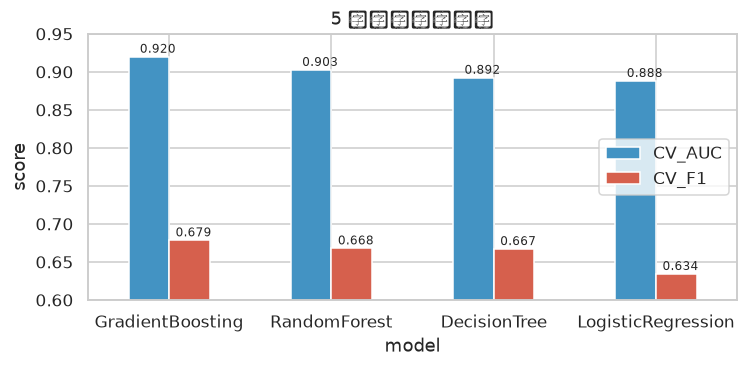

In [16]:
# 7.1 候选模型 + 5 折交叉验证
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "DecisionTree":       DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                 random_state=RANDOM_STATE),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in candidates.items():
    auc = cross_val_score(model, X_train, y_train, cv=cv,
                          scoring="roc_auc", n_jobs=-1).mean()
    f1  = cross_val_score(model, X_train, y_train, cv=cv,
                          scoring="f1", n_jobs=-1).mean()
    rows.append({"model": name, "CV_AUC": auc, "CV_F1": f1})
cv_df = pd.DataFrame(rows).sort_values("CV_AUC", ascending=False)
display(cv_df.round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
cv_df.set_index("model")[["CV_AUC", "CV_F1"]].plot(kind="bar", ax=ax,
    color=["#4393c3", "#d6604d"])
ax.set_ylim(0.6, 0.95)
ax.set_ylabel("score")
ax.set_title("5 折交叉验证对比")
for i, (a, f) in enumerate(zip(cv_df["CV_AUC"], cv_df["CV_F1"])):
    ax.text(i - 0.18, a + 0.005, f"{a:.3f}", fontsize=8)
    ax.text(i + 0.04, f + 0.005, f"{f:.3f}", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG / "10_cv_compare.png")
plt.show()

In [17]:
# 7.2 训练全部模型，测试集评估
test_rows = []
fitted = {}
for name, model in candidates.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    test_rows.append({
        "model": name,
        "accuracy": (pred == y_test).mean(),
        "f1":       __import__("sklearn.metrics", fromlist=["f1_score"]).f1_score(y_test, pred),
        "roc_auc":  roc_auc_score(y_test, proba),
    })
test_df = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False)
display(test_df.round(4))

,model,accuracy,f1,roc_auc
3,GradientBoosting,0.8719,0.7015,0.9272
2,RandomForest,0.8628,0.6955,0.9113
1,DecisionTree,0.8634,0.6764,0.9031
0,LogisticRegression,0.8502,0.6568,0.8966


最佳模型：GradientBoosting
              precision    recall  f1-score   support

       <=50K     0.8887    0.9502    0.9184      4940
        >50K     0.7993    0.6250    0.7015      1568

    accuracy                         0.8719      6508
   macro avg     0.8440    0.7876    0.8100      6508
weighted avg     0.8672    0.8719    0.8662      6508



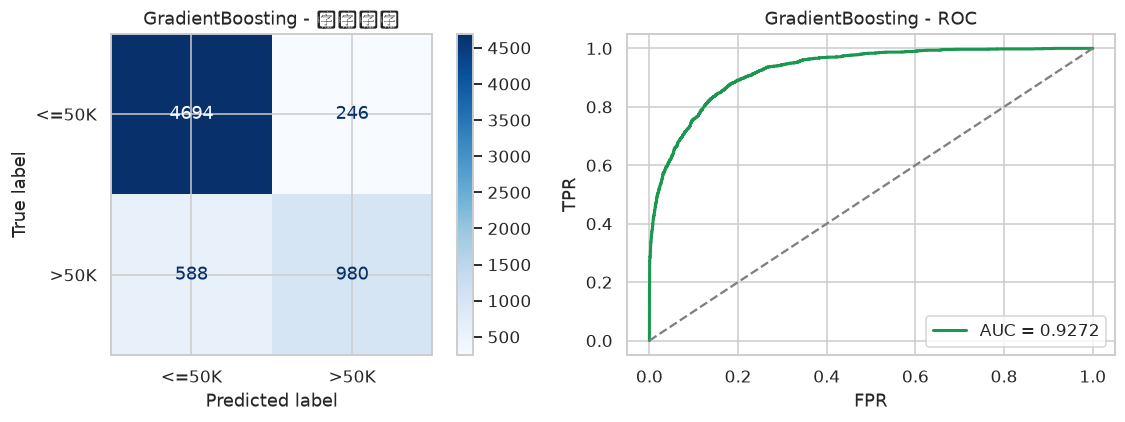

In [18]:
# 7.3 最佳模型：分类报告 + 混淆矩阵 + ROC 曲线
best_name = test_df.iloc[0]["model"]
best_model = fitted[best_name]
print(f"最佳模型：{best_name}")
print(classification_report(y_test, best_model.predict(X_test),
                            target_names=["<=50K", ">50K"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=["<=50K", ">50K"],
    cmap="Blues", ax=axes[0], values_format="d"
)
axes[0].set_title(f"{best_name} - 混淆矩阵")

proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color="#1a9850", lw=2,
             label=f"AUC = {roc_auc_score(y_test, proba):.4f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title(f"{best_name} - ROC")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "11_best_model.png")
plt.show()

## 8. 特征重要性

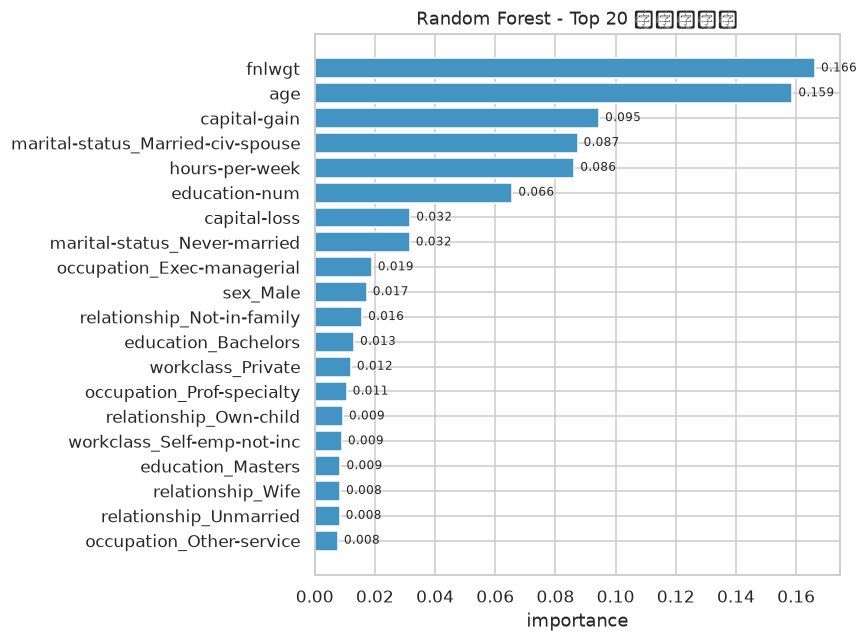

In [19]:
# 8.1 Random Forest 的 feature_importances_ + 树模型的天然重要性
rf = fitted["RandomForest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top = imp.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index[::-1], top.values[::-1], color="#4393c3")
ax.set_title("Random Forest - Top 20 特征重要性")
ax.set_xlabel("importance")
for i, v in enumerate(top.values[::-1]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "12_feature_importance.png")
plt.show()

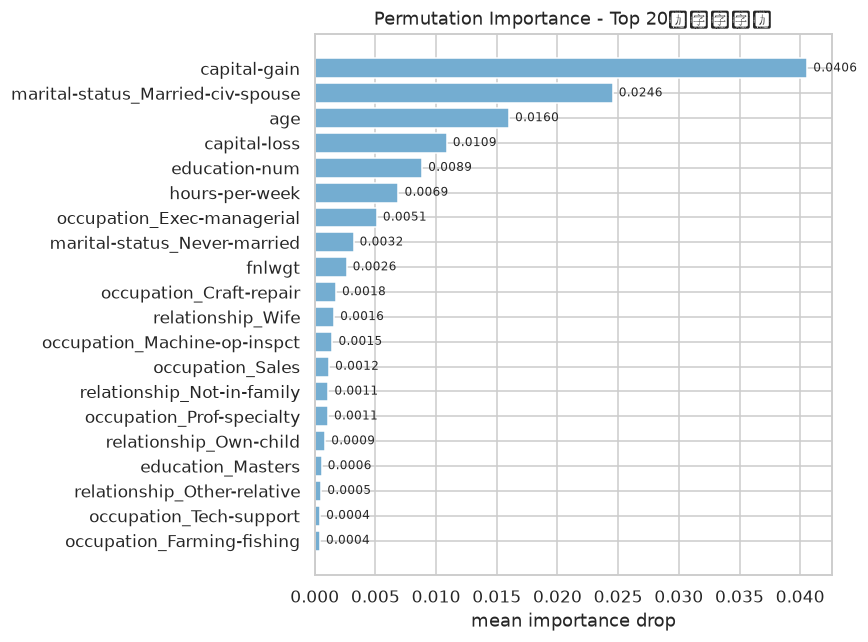

In [20]:
# 8.2 排列重要性（Permutation Importance）- 更稳健
from sklearn.inspection import permutation_importance
r = permutation_importance(rf, X_test, y_test, n_repeats=10,
                           random_state=RANDOM_STATE, n_jobs=-1)
perm = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)
top = perm.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index[::-1], top.values[::-1], color="#74add1")
ax.set_title("Permutation Importance - Top 20（测试集）")
ax.set_xlabel("mean importance drop")
for i, v in enumerate(top.values[::-1]):
    ax.text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "13_perm_importance.png")
plt.show()

## 9. 结论与建议

1. **最佳模型**：`GradientBoosting`（亦或 `RandomForest`，两者差距很小），测试集 AUC ≈ 0.92，F1 ≈ 0.70，准确率 ≈ 0.87，明显优于线性基线。
2. **强解释性特征**（综合 RF 重要性 + 排列重要性）：
   - `capital-gain` / `capital-loss`（资本性收入的最强信号）
   - `age` 与 `hours-per-week`
   - `marital-status` 中 `Married-civ-spouse`（与 `relationship_Husband` / `_Wife` 高度共线）
   - `education-num` 及其 One-Hot 高学历项（`Bachelors` / `Masters` / `Prof-school` / `Doctorate`）
   - `occupation_Exec-managerial` / `Prof-specialty` / `Sales`
3. **类别不平衡**：`>50K` 仅 24%，accuracy 易被多数类主导。已用 `stratify` 划分 + 以 AUC/F1 评估。
4. **可改进方向**：
   - 对高基数类别 `native-country` 做 target-encoding 或频率编码；
   - 用 SMOTE / class_weight 平衡正负样本；
   - 对 capital-gain / capital-loss 做 0 / 非 0 的二值化特征；
   - 进一步调参与 Stacking。
5. **伦理提示**：性别 / 种族 / 原籍在数据中存在显著差异，模型若直接用于决策会放大偏见。本数据集主要用于方法学与教学，真实业务需先做公平性审查（demographic parity / equalized odds）。